In [74]:
# %load_ext cuml.accel

# Credit Card Fraud Detection 
## 1. Introduction
Credit Card transaction fraud detection is an *imbalanced classification problem*. Since, fraudulent transactions occurs rarely w.r.t legitmate ones it became more challenging.

**Notebook Application**:  
The notebook solves problems using:
* XGBoost algorithm for fraud detection.
* MLflow to track mlprocess and results.

In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV

from imblearn.over_sampling import SMOTE 
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score,accuracy_score,f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, TargetEncoder


## 2. Data Loading and Initial Overview
* Loading the dataset and performing an initial check is the first step in any ML project.  
load dataset and perform initial screening is first step in any ML projet.
Analyzing and understanding dataset structure that will guides preprocessing

In [76]:
# load dataset
df = pd.read_csv('credit_card_transactions.csv')
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

In [77]:
df = df.sample(frac=0.1, random_state=42)

**2. Dataset Overview**
This dataset contains credit crard transaction details along with merchant, customer details.

#### Columns (before processing):
* Unnamed: 0 -- index column
* cc_num: Credit card number.
* first, last: Customer first/last name 
* trans_date_trans_time: Transaction date & time
* unix_time: Unix timestamp 

* dob:  date of birth of customer
* gender:  gender.

* street, city, state, zip, city_pop: Location-related features.

* lat, long: Customer latitude/longitude.

* merch_lat, merch_long: Merchant latitude/longitude.

* merchant: Merchant name.

* category: transaction type.

* amt: Transaction amount.

* job: Customer job.

* merch_zipcode: Merchant’s ZIP code.

* is_fraud: Target variable 


In [78]:
df = df.drop(columns=["Unnamed: 0", "cc_num", "first", "last",'lon','street','merch_zipcode','city_pop','zip','unix_time'], errors="ignore")


## 3. Feature Engineering, Feature selection and data cleaning
***Dropped columns:***
Unnamed: 0

cc_num

first, last, street, merch_zipcode, city_pop, zip, unix_time

* Removing unnecessary columns reduces noises and speedup training.

***Date and time processing***
* convert datetime to strings

and extract new features from datetime:
* trans_year → transaction year

* trans_month → transaction month

* trans_day → transaction day

* trans_hour → Hour of the day 

* trans_weekday → Day of the week 

* is_weekend → Boolean 

* ***Age Feature from dob*** age is derrived from dob, makes more reasonable output.
* ***Categorical Encoding***

In [79]:
# datetime management
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], 
                                             format="%Y-%m-%d %H:%M:%S",
                                             errors="coerce")
df['dob'] = pd.to_datetime(df['dob'], errors="coerce")

In [80]:
# transaction time feature
df['trans_year'] = df['trans_date_trans_time'].dt.year
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_weekday'] = df['trans_date_trans_time'].dt.weekday
df['is_weekend'] = df['trans_date_trans_time'].dt.weekday >= 5


#### Customer age

In [81]:
# age from dob
df['age'] = (df['trans_date_trans_time'].dt.year - df[ 
  'dob'].dt.year)

### Data types and features
#### Numerical columns
* amt: Transaction amount

* lat, long: Customer location

* merch_lat, merch_long: Merchant location

* trans_year, trans_month, trans_day, trans_hour, trans_weekday

* is_weekend

* age


### Categorical columns
* gender

* category

* state

* job

* merchant

---> Encoded using:
* LabelEncoder: for binary
* OneHotEncoder: feature with low cardinal fcategory
* TargetEncoder: feature with high cardinal category


In [82]:
df = df.drop(columns=['trans_date_trans_time','dob'])
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 129668 entries, 1045211 to 879092
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   merchant       129668 non-null  object 
 1   category       129668 non-null  object 
 2   amt            129668 non-null  float64
 3   gender         129668 non-null  object 
 4   city           129668 non-null  object 
 5   state          129668 non-null  object 
 6   lat            129668 non-null  float64
 7   long           129668 non-null  float64
 8   job            129668 non-null  object 
 9   trans_num      129668 non-null  object 
 10  merch_lat      129668 non-null  float64
 11  merch_long     129668 non-null  float64
 12  is_fraud       129668 non-null  int64  
 13  trans_year     129668 non-null  int32  
 14  trans_month    129668 non-null  int32  
 15  trans_day      129668 non-null  int32  
 16  trans_hour     129668 non-null  int32  
 17  trans_weekday  129668 non-nu

In [83]:
y = df['is_fraud']
X = df.drop('is_fraud',axis=1)

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)

In [85]:
num_cols = ['amt', 'lat', 'long', 'merch_lat', 'merch_long',
                    'trans_year', 'trans_month', 'trans_day', 'trans_hour',
                    'trans_weekday', 'is_weekend', 'age']
                                                            
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

In [86]:
cat_low_cols = ['gender', 'category', 'state']
cat_high_cols = ['merchant', 'city', 'job']
for col in cat_low_cols + cat_high_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

In [87]:

# Convert 'amt' to numeric, coercing errors
df['amt'] = pd.to_numeric(df['amt'], errors='coerce')

# Encode categorical
cat_low_cols = ['gender', 'category', 'state']
cat_high_cols = ['merchant', 'city']
num_cols = ['amt', 'lat', 'long', 
                    'trans_year', 'trans_month', 'trans_day', 'trans_hour',
                    'trans_weekday', 'is_weekend', 'age']

# missing values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_low_cols + cat_high_cols] = df[cat_low_cols + cat_high_cols].fillna("Unknown")

In [88]:

y.isna()

1045211    False
547406     False
110142     False
1285953    False
271705     False
           ...  
707445     False
238797     False
895771     False
1137189    False
879092     False
Name: is_fraud, Length: 129668, dtype: bool

In [89]:
print(df.nunique())

merchant            693
category             14
amt               22888
gender                2
city                870
state                50
lat                 939
long                940
job                 483
trans_num        129668
merch_lat        129182
merch_long       129471
is_fraud              2
trans_year            2
trans_month          12
trans_day            31
trans_hour           24
trans_weekday         7
is_weekend            2
age                  83
dtype: int64


In [90]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [c for c in num_cols if c in X_train.columns]),
        ('cat_low', OneHotEncoder(handle_unknown='ignore'), [c for c in cat_low_cols if c in X_train.columns]),    
    ]
)

In [91]:
X_train_low = preprocessor.fit_transform(X_train, y_train)
X_test_low = preprocessor.transform(X_test)

In [92]:
print(X_train_low.shape)
print(X_test_low.shape)
print(X_train_low.dtype)
print(X_test_low.dtype)



(103734, 76)
(25934, 76)
float64
float64


In [93]:
tar_enc = TargetEncoder()
X_train_high = tar_enc.fit_transform(X_train[cat_high_cols],y_train)
X_test_high = tar_enc.transform(X_test[cat_high_cols])



In [94]:
print(X_train_high.shape)
print(X_test_high.shape)
print(X_train_high.dtype)
print(X_test_high.dtype)

(103734, 2)
(25934, 2)
float64
float64


In [95]:
from scipy.sparse import issparse

if issparse(X_train_low):
    X_train_low = X_train_low.toarray()
if issparse(X_test_low):
    X_test_low = X_test_low.toarray()

if X_train_high.ndim == 1:
    X_train_high = X_train_high.reshape(-1, 1)
if X_test_high.ndim == 1:
    X_test_high = X_test_high.reshape(-1, 1)

In [96]:

import numpy as np
X_train_processed = np.hstack([X_train_low, X_train_high])
X_test_processed = np.hstack([X_test_low, X_test_high])

In [98]:
df.select_dtypes(include=['object']).columns

Index(['merchant', 'category', 'gender', 'city', 'state', 'job', 'trans_num'], dtype='object')

In [99]:
X.dtypes

merchant          object
category          object
amt              float64
gender            object
city              object
state             object
lat              float64
long             float64
job               object
trans_num         object
merch_lat        float64
merch_long       float64
trans_year         int32
trans_month        int32
trans_day          int32
trans_hour         int32
trans_weekday      int32
is_weekend          bool
age                int32
dtype: object

### Handling Class Imbalance
SMOTE is used in training data set.  It generates synthetic samples for minority class.

In [100]:
print("Before SMOTE:")
print(y_train.value_counts())
print(f"Dataset shape: {X_train_processed.shape}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
print(f"Balanced dataset shape: {X_train_balanced.shape}")

Before SMOTE:
is_fraud
0    103116
1       618
Name: count, dtype: int64
Dataset shape: (103734, 78)

After SMOTE:
is_fraud
0    103116
1    103116
Name: count, dtype: int64
Balanced dataset shape: (206232, 78)


### Model Training
* Model used: XGBoost Classifier.
----> pipeline:
* column transformer for handling cateegorical data
* standardscaler standardizes numerical values


## Model Evaluation
* Since, this is classification problem and also have imbalanced dataset. so, model evaluation goes beyond accuracy
Key metrics:  
- **Confusion Matrix** → fraud vs non fraud detetion
- **ROC-AUC Score** → Measures overall discrimination ability.  
- **F1-score** → Used in imbalanced dataset. Balances precision and recall 

In [ ]:
# hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
   objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)



random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=10,              
    scoring='roc_auc',      
    cv=3,                    
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_balanced, y_train_balanced)

print("Best Parameters Found:")
print(random_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


d:\AMNIL-Internship\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:22:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters Found:
{'subsample': 0.6, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [118]:

#get the best model and retrain on balanced data
best_xgb = random_search.best_estimator_
best_xgb.fit(X_train_balanced, y_train_balanced)
best_params_xgb = random_search.best_params_


d:\AMNIL-Internship\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:56:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [104]:


#
# Predictions
y_pred = best_xgb.predict(X_test_processed)
y_prob = best_xgb.predict_proba(X_test_processed)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25779
           1       0.88      0.79      0.83       155

    accuracy                           1.00     25934
   macro avg       0.94      0.89      0.91     25934
weighted avg       1.00      1.00      1.00     25934

ROC-AUC: 0.9903710071588653


In [105]:
import shap
import matplotlib.pyplot as plt


d:\AMNIL-Internship\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


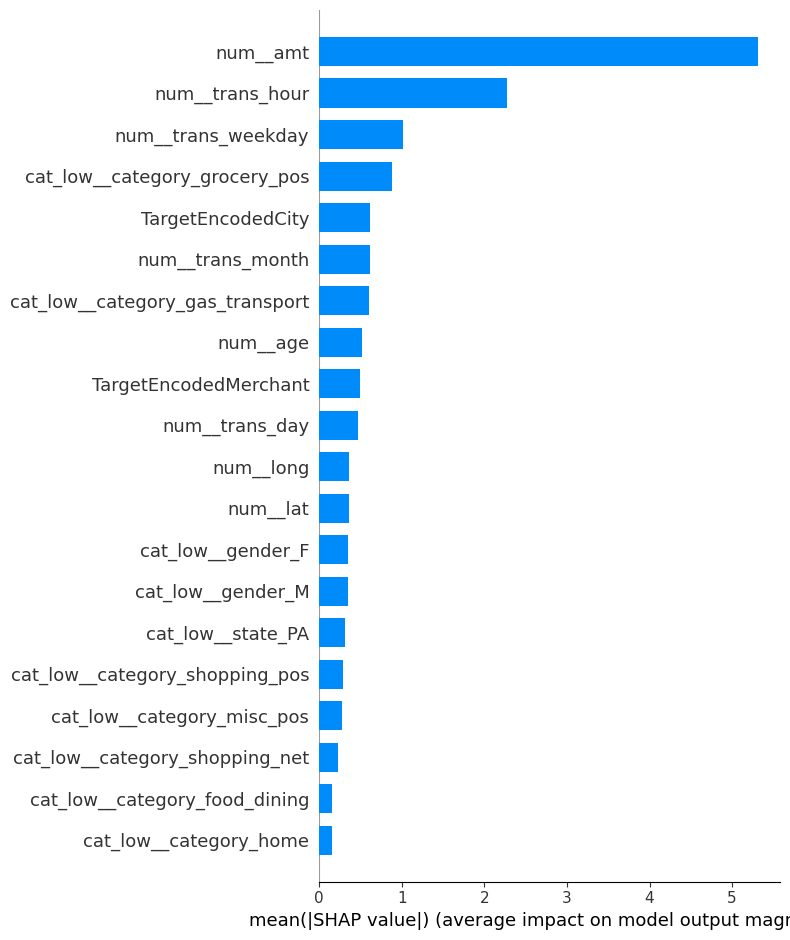

<Figure size 640x480 with 0 Axes>

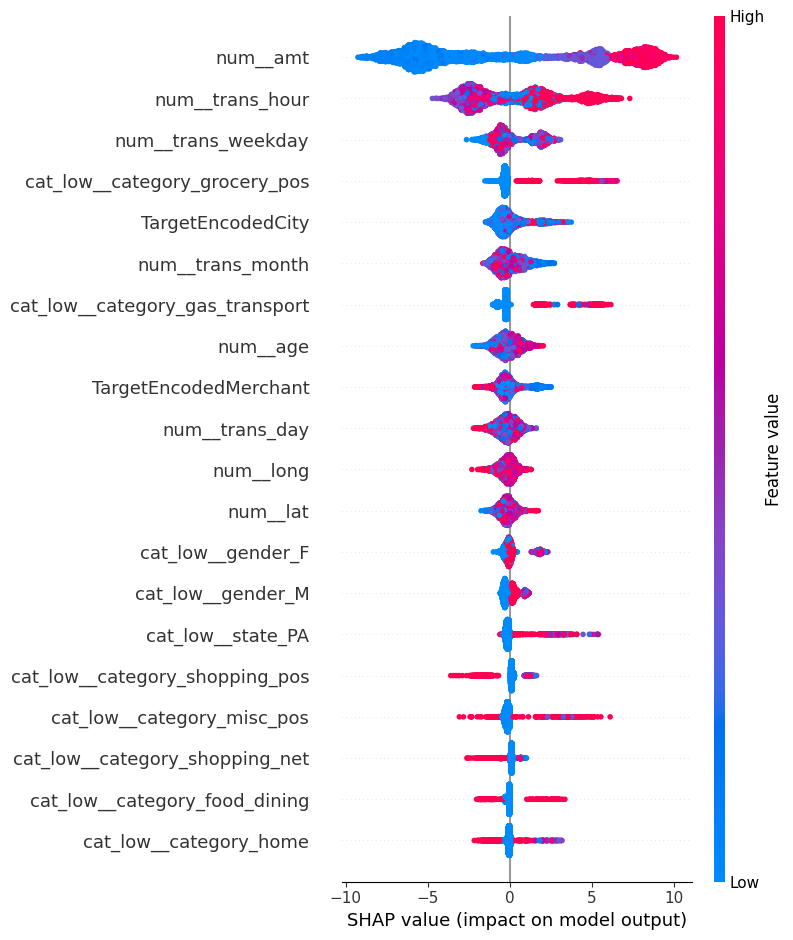

<Figure size 640x480 with 0 Axes>

In [106]:
feature_names = list(preprocessor.get_feature_names_out())

feature_names.extend(['TargetEncodedMerchant', 'TargetEncodedCity'])

X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=feature_names)

sample = X_train_balanced_df.sample(5000, random_state=42)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(sample)

# Plots
plt.figure(figsize=(4, 3))  
shap.summary_plot(shap_values.values, sample, plot_type="bar")
plt.tight_layout()
plt.figure(figsize=(4, 3))  
shap.summary_plot(shap_values.values, sample)
plt.tight_layout()

In [107]:
import scipy.stats as sps

from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier


In [108]:
param_rf = {
    'n_estimators': sps.randint(100, 401),        # 100..400 inclusive -> randint(100,401)
    'max_depth': sps.randint(2, 11),              # 2..10 inclusive
    'min_samples_split': sps.randint(2, 11),
    'min_samples_leaf': sps.randint(1, 11),
    'max_features': ['sqrt', 'log2']
}

rf_estimator = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

random_search_rf = RandomizedSearchCV(
    estimator=rf_estimator,
    param_distributions=param_rf,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train_balanced, y_train_balanced)

print("Best Parameters Found:")
print(random_search_rf.best_params_)

#get the best model and retrain on balanced data
best_rf = random_search_rf.best_estimator_
best_rf.fit(X_train_balanced, y_train_balanced)

y_pred = best_rf.predict(X_test_processed)
y_prob = best_rf.predict_proba(X_test_processed)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 4, 'n_estimators': 154}
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     25779
           1       0.33      0.78      0.46       155

    accuracy                           0.99     25934
   macro avg       0.66      0.89      0.73     25934
weighted avg       0.99      0.99      0.99     25934

ROC-AUC: 0.9591145080579467


In [ ]:
best_params_rf = random_search_rf.best_params_


{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 4, 'n_estimators': 154}


In [109]:
! pip install lightgbm


In [110]:
import lightgbm as lgb

In [123]:

param_lgb = {
    'num_leaves': [20, 31, 40, 50, 60, 70, 80],              # controls tree complexity
    'max_depth': [-1, 5, 7, 9, 11, 13],                      # -1 means no limit
    'learning_rate': [0.01, 0.03, 0.05, 0.1],                # lower values → slower but better convergence
    'n_estimators': [100, 200, 300, 400, 500],               # number of boosting rounds
    'min_child_samples': [10, 20, 30, 40, 50],               # minimum data in one leaf
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],                  # bagging fraction for boosting    
}

lgb_estimator = lgb.LGBMClassifier(
    random_state=42,
    class_weight='balanced'
)

random_search_lgb = RandomizedSearchCV(
    estimator=lgb_estimator,
    param_distributions=param_lgb,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_lgb.fit(X_train_balanced, y_train_balanced)
 

print("Best Parameters Found:")
print(random_search_rf.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 103116, number of negative: 103116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070311 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18828
[LightGBM] [Info] Number of data points in the train set: 206232, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best Parameters Found:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 4, 'n_estimators': 154}


In [124]:

#get the best model and retrain on balanced data
best_lgb = random_search_lgb.best_estimator_
best_lgb.fit(X_train_balanced, y_train_balanced)

y_pred = best_lgb.predict(X_test_processed)
y_prob = best_lgb.predict_proba(X_test_processed)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[LightGBM] [Info] Number of positive: 103116, number of negative: 103116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.112189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18828
[LightGBM] [Info] Number of data points in the train set: 206232, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


d:\AMNIL-Internship\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\AMNIL-Internship\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25779
           1       0.90      0.79      0.84       155

    accuracy                           1.00     25934
   macro avg       0.95      0.90      0.92     25934
weighted avg       1.00      1.00      1.00     25934

ROC-AUC: 0.9955184827860637


In [125]:
best_params_lgb = random_search_lgb.best_params_


In [126]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [130]:
models = [
    (
        "XGBoost", 
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', **best_params_xgb), 
        (X_train_balanced, y_train_balanced),
        (X_test_processed, y_test)
    ),
    (
        "Random Forest",
        RandomForestClassifier(class_weight='balanced', random_state=42, **best_params_rf),
        (X_train_balanced, y_train_balanced),
        (X_test_processed, y_test)
    ),
    (
        "LGBM",
        LGBMClassifier(class_weight='balanced', random_state=42, **best_params_lgb),
        (X_train_balanced, y_train_balanced),
        (X_test_processed, y_test)
    )
]

In [131]:
reports = []

for model_name, model, train_set, test_set in models:
    X_train_mlf, y_train_mlf = train_set
    X_test_mlf, y_test_mlf = test_set  # test_set should be (X_test, y_test)

    # Train on training set
    model.fit(X_train_mlf, y_train_mlf)

    # Predict on test set
    y_pred = model.predict(X_test_mlf)

    # Evaluation
    report = classification_report(y_test_mlf, y_pred, output_dict=True)
    reports.append((model_name, report))


d:\AMNIL-Internship\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:18:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 103116, number of negative: 103116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18828
[LightGBM] [Info] Number of data points in the train set: 206232, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


d:\AMNIL-Internship\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [133]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

In [135]:
for i, element in enumerate(models):
    model_name = element[0]
    model = element[1]
    _, report = reports[i]  # unpack tuple: ignore first element, get report dict

    with mlflow.start_run(run_name=model_name):        
        mlflow.log_param("model", model_name)
        mlflow.log_metric('accuracy', report['accuracy'])
        mlflow.log_metric('recall_class_1', report['1']['recall'])
        mlflow.log_metric('recall_class_0', report['0']['recall'])
        mlflow.log_metric('f1_score_macro', report['macro avg']['f1-score'])        
        
        if "XGB" in model_name:
            mlflow.xgboost.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")


2025/10/08 12:25:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\AMNIL-Internship\myenv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [12:25:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/10/08 12:25:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run XGBoost at: http://localhost:5000/#/experiments/809393929840980209/runs/0c5fdbf6c40d45dbbe11431abec89cf8
🧪 View experiment at: http://localhost:5000/#/experiments/809393929840980209


2025/10/08 12:25:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/08 12:25:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Random Forest at: http://localhost:5000/#/experiments/809393929840980209/runs/b3effbbf60db41d0898b1ea481542f42
🧪 View experiment at: http://localhost:5000/#/experiments/809393929840980209


2025/10/08 12:25:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/08 12:26:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run LGBM at: http://localhost:5000/#/experiments/809393929840980209/runs/6f08e76e051f43829b208c4b8ce63a3c
🧪 View experiment at: http://localhost:5000/#/experiments/809393929840980209
